In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

filename = "b324whg.txt"

data = np.genfromtxt(
    filename,
    skip_header=1,
    dtype=str
)

mjd = data[:, 0].astype(float)

V_mag_raw = data[:, 1]
V_err_raw = data[:, 2]

valid_mag = V_mag_raw != "--.---"

valid_err = V_err_raw != "-.---"

mask = valid_mag & valid_err

mjd = mjd[mask]
V_mag = V_mag_raw[mask].astype(float)
V_err = V_err_raw[mask].astype(float)

print("Number of good V points:", len(V_mag))

Number of good V points: 73


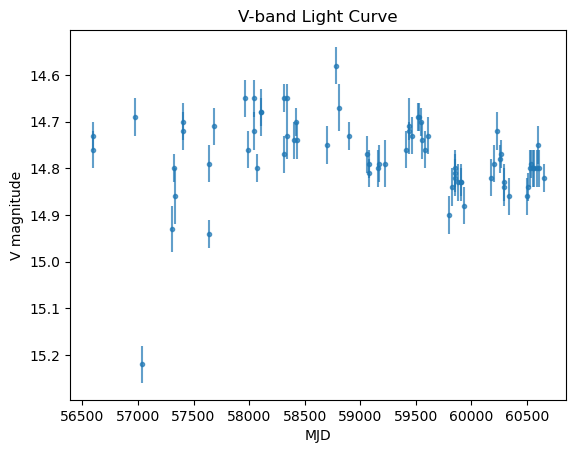

In [2]:
plt.figure()
plt.errorbar(mjd, V_mag, yerr=V_err, fmt='.', alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel("MJD")
plt.ylabel("V magnitude")
plt.title("V-band Light Curve")
plt.show()

In [ ]:
min_freq = 0.0001   
max_freq = 0.2     

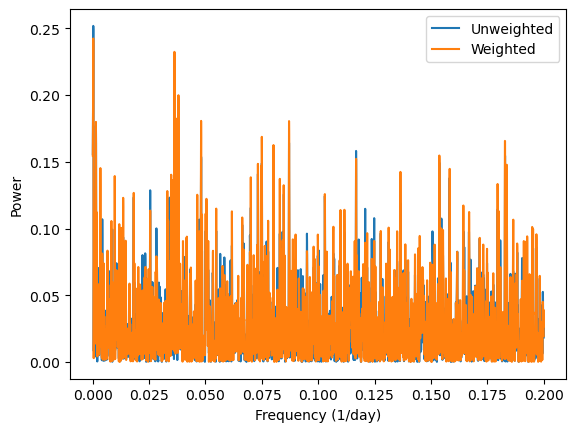

In [4]:
ls_unweighted = LombScargle(mjd, V_mag)
frequency, power_unweighted = ls_unweighted.autopower(
    minimum_frequency=min_freq,
    maximum_frequency=max_freq
)

ls_weighted = LombScargle(mjd, V_mag, dy=V_err)
power_weighted = ls_weighted.power(frequency)

plt.figure()
plt.plot(frequency, power_unweighted, label="Unweighted")
plt.plot(frequency, power_weighted, label="Weighted")
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.show()

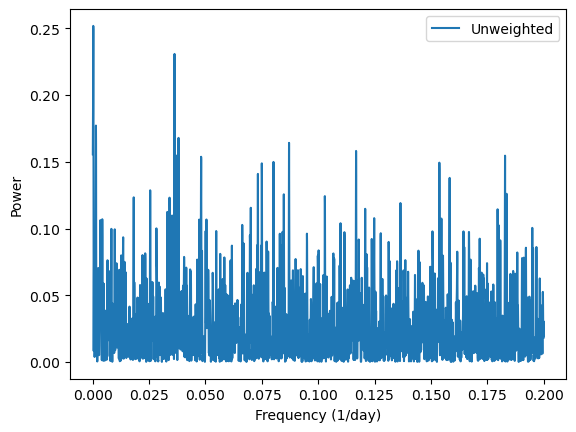

In [5]:
ls_unweighted = LombScargle(mjd, V_mag)
frequency, power_unweighted = ls_unweighted.autopower(
    minimum_frequency=min_freq,
    maximum_frequency=max_freq
)

plt.figure()
plt.plot(frequency, power_unweighted, label="Unweighted")
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.show()

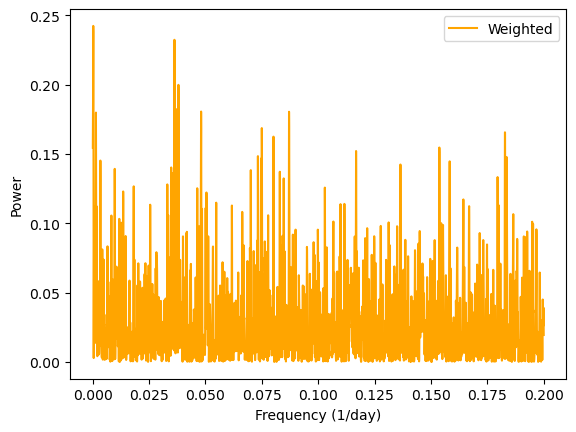

In [6]:
ls_weighted = LombScargle(mjd, V_mag, dy=V_err)
power_weighted = ls_weighted.power(frequency)

plt.figure()
plt.plot(frequency, power_weighted, label="Weighted", color='orange')
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.show()

In [7]:
best_freq = frequency[np.argmax(power_weighted)]
best_period = 1 / best_freq

print("Best period (days):", best_period)

Best period (days): 3365.400563940952


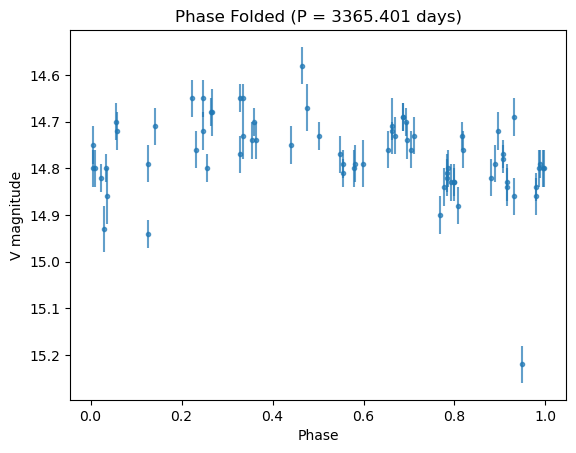

In [8]:
phase = (mjd % best_period) / best_period

plt.figure()
plt.errorbar(phase, V_mag, yerr=V_err, fmt='.', alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel("Phase")
plt.ylabel("V magnitude")
plt.title(f"Phase Folded (P = {best_period:.3f} days)")
plt.show()

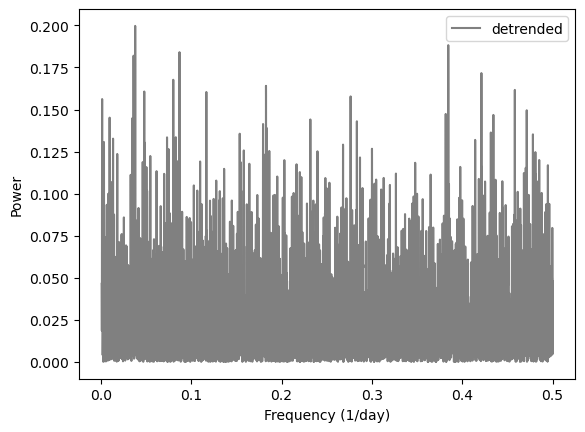

In [9]:
from scipy.signal import detrend

V_detrended = detrend(V_mag)

ls = LombScargle(mjd, V_detrended, dy=V_err)
frequency, power = ls.autopower(minimum_frequency=0.001, maximum_frequency=0.5)

plt.figure()
plt.plot(frequency, power, label="detrended", color='grey')
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.show()

In [10]:
best_power = np.max(power)
fap = ls.false_alarm_probability(best_power)
print("False Alarm Probability:", fap)

False Alarm Probability: 0.19564647482272188


Number of good V points: 74


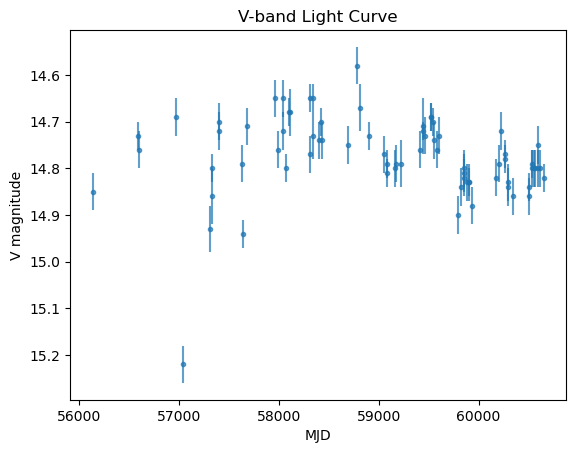

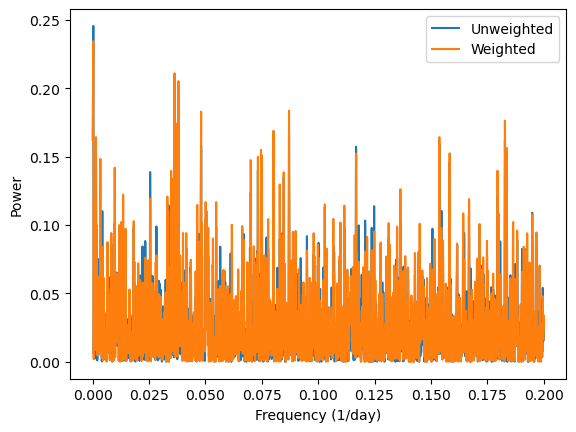

Best period (days): 3108.5716963526456
Phase-folded amplitude (mag): 0.2370000000000001


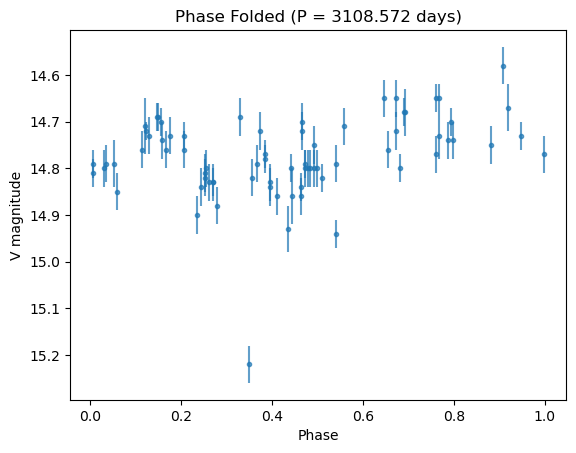

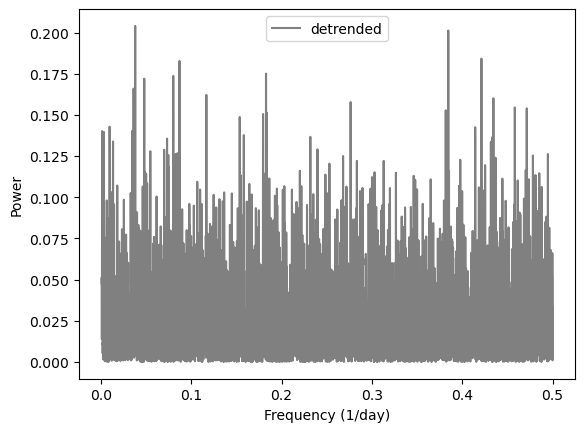

False Alarm Probability: 0.14316565069644396


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

filename = "b324whg.txt"

data = np.genfromtxt(
    filename,
    dtype=str,
    usecols=(0,1,2),   
    invalid_raise=False
)

mjd = data[:, 0].astype(float)

V_mag_raw = data[:, 1]
V_err_raw = data[:, 2]

mask = (
    (V_mag_raw != "--.---") &
    (V_err_raw != "-.---") &
    (V_mag_raw != "") &
    (V_err_raw != "") &
    (V_mag_raw != ">") &
    (V_err_raw != ">") &
    (~np.char.startswith(V_mag_raw, ">")) &
    (~np.char.startswith(V_err_raw, ">"))
)

mjd = mjd[mask]
V_mag = V_mag_raw[mask].astype(float)
V_err = V_err_raw[mask].astype(float)

print("Number of good V points:", len(V_mag))

plt.figure()
plt.errorbar(mjd, V_mag, yerr=V_err, fmt='.', alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel("MJD")
plt.ylabel("V magnitude")
plt.title("V-band Light Curve")
plt.show()


min_freq = 0.0001  
max_freq = 0.2     


ls_unweighted = LombScargle(mjd, V_mag)
frequency, power_unweighted = ls_unweighted.autopower(
    minimum_frequency=min_freq,
    maximum_frequency=max_freq
)

ls_weighted = LombScargle(mjd, V_mag, dy=V_err)
power_weighted = ls_weighted.power(frequency)

plt.figure()
plt.plot(frequency, power_unweighted, label="Unweighted")
plt.plot(frequency, power_weighted, label="Weighted")
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.show()


best_freq = frequency[np.argmax(power_weighted)]
best_period = 1 / best_freq

print("Best period (days):", best_period)


phase = (mjd % best_period) / best_period

idx = np.argsort(phase)
phase_sorted = phase[idx]
mag_sorted = V_mag[idx]

amp_phase = np.percentile(mag_sorted, 95) - np.percentile(mag_sorted, 5)
print("Phase-folded amplitude (mag):", amp_phase)

plt.figure()
plt.errorbar(phase, V_mag, yerr=V_err, fmt='.', alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel("Phase")
plt.ylabel("V magnitude")
plt.title(f"Phase Folded (P = {best_period:.3f} days)")
plt.show()


from scipy.signal import detrend

V_detrended = detrend(V_mag)

ls = LombScargle(mjd, V_detrended, dy=V_err)
frequency, power = ls.autopower(minimum_frequency=0.001, maximum_frequency=0.5)

plt.figure()
plt.plot(frequency, power, label="detrended", color='grey')
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.show()

best_power = np.max(power)
fap = ls.false_alarm_probability(best_power)
print("False Alarm Probability:", fap)

Processing star: b324whg
Error column found — using real error bars.
Good V points: 73


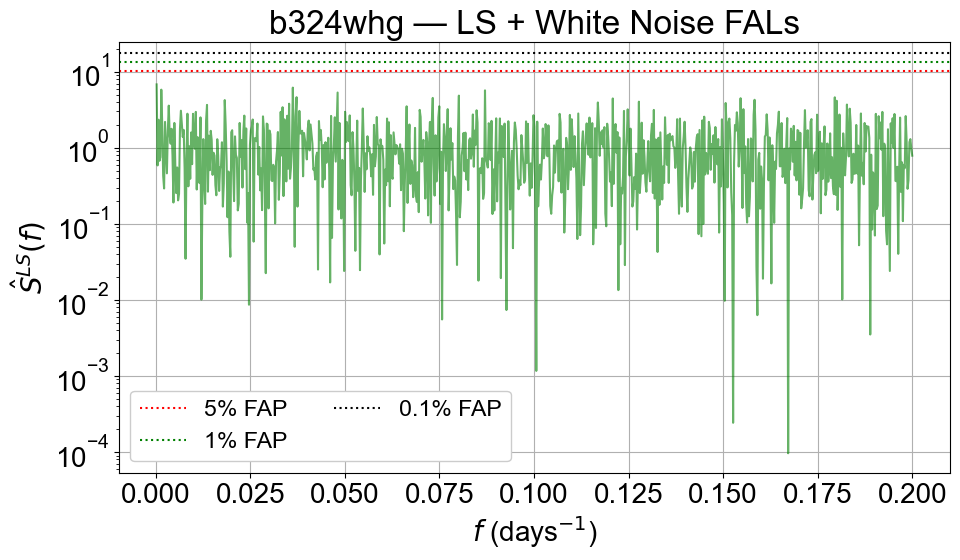

----------------------- POWER LAW FITTING RESULTS -------------------
Optimization terminated successfully.
Slope = -0.08
Intercept = -0.06
Whittle negative log-likelihood = 869.79
----------------------- AR(1) FITTING RESULTS -------------------
Optimization terminated successfully.
Phi = 0.08
Sigma = 0.98
Whittle negative log-likelihood = 872.00
----------------------- WHITE NOISE FITTING RESULTS -------------------
Optimization terminated successfully.
Power of white noise = 1.08
Whittle negative log-likelihood = 872.58


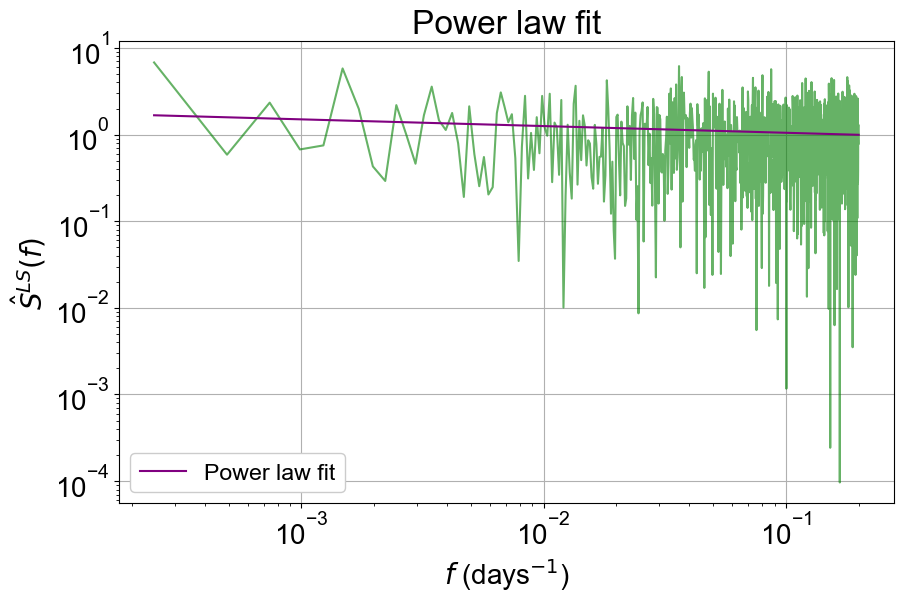

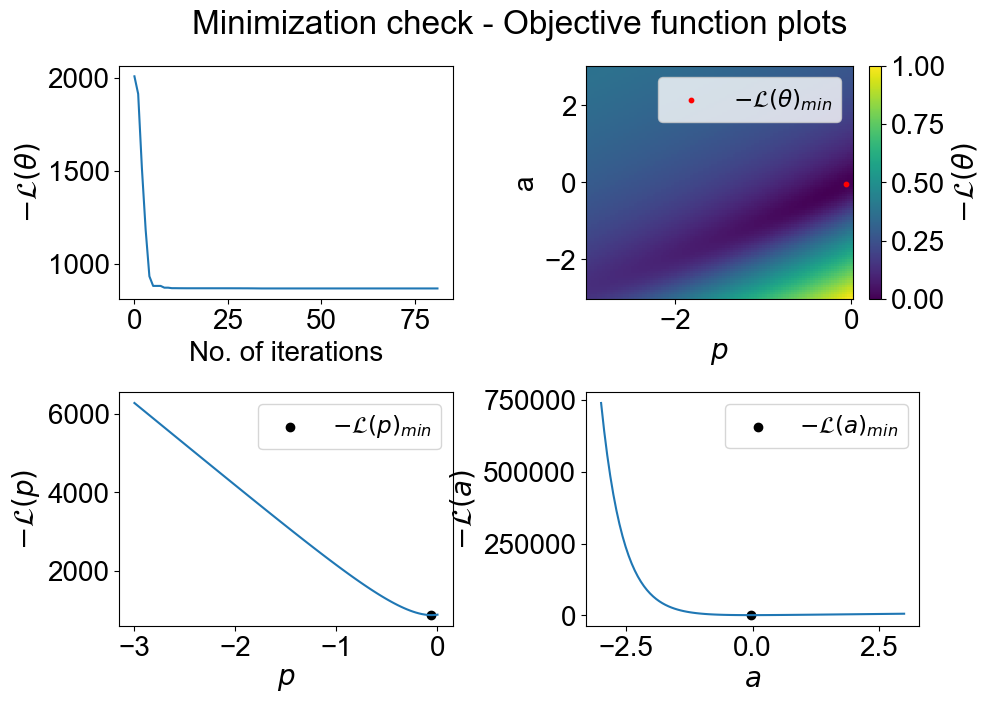

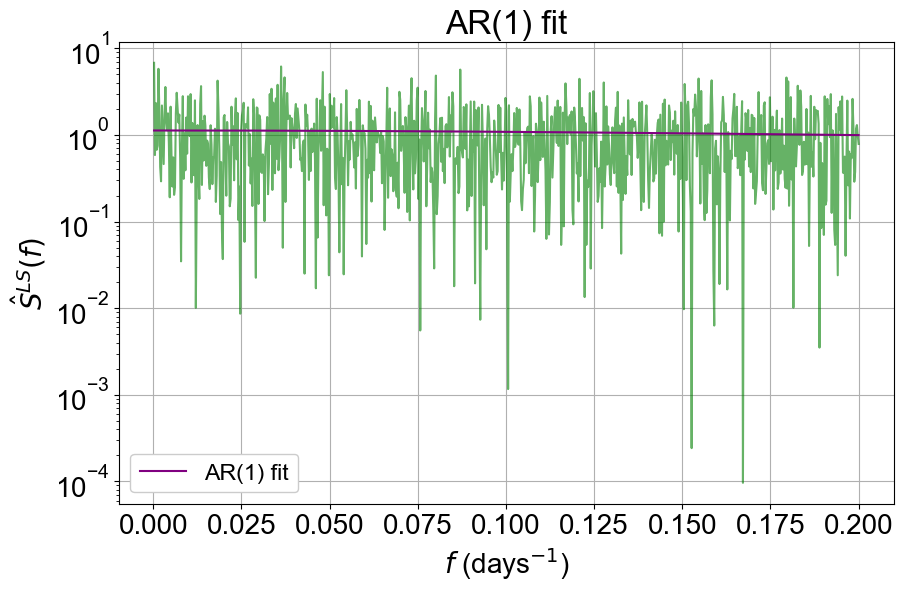

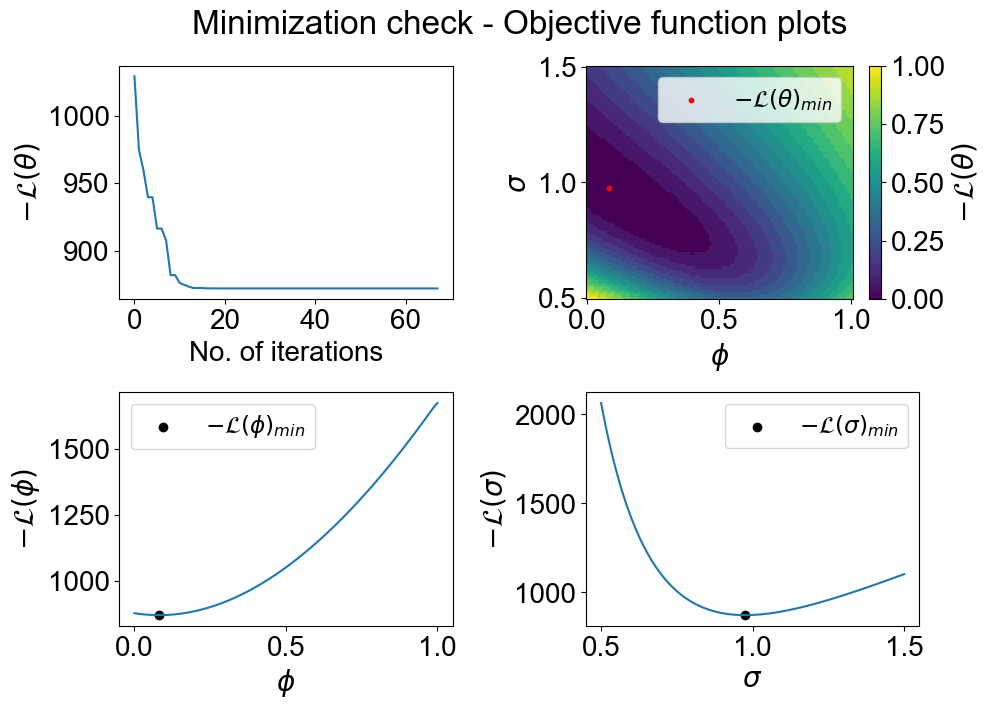

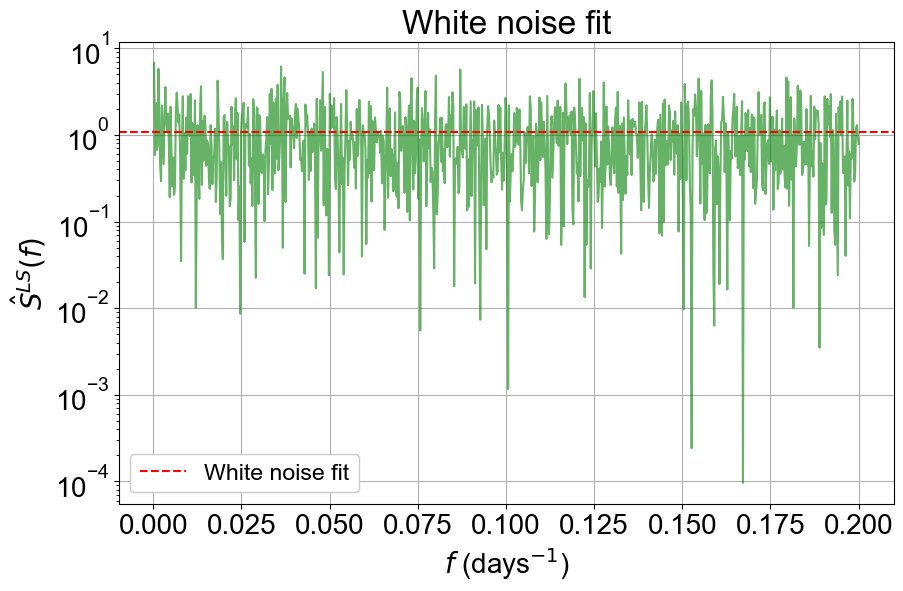

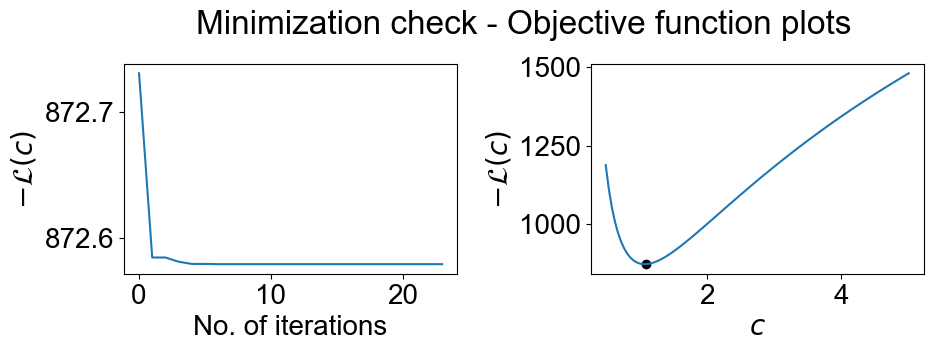


── Model comparison for b324whg (lower NLL = better) ──
  Power law   NLL: 869.79  | slope=-0.08, intercept=-0.06
  AR(1)       NLL: 872.00 | phi=0.08, sigma=0.98
  White noise NLL: 872.58  | power=1.08
  → Best model: Power law

Loading existing bootstrap results from b324whg_fitting_results.txt
  Median NLL — PL: 1017.19, AR(1): 1019.06, WN: 1019.22


/var/folders/f1/ycblpyz16531mms2vrj6yt7c0000gn/T/ipykernel_3348/1311837944.py:143: RuntimeWarning: divide by zero encountered in log
  tau         = -1.0 / np.log(np.abs(phi_j))
/var/folders/f1/ycblpyz16531mms2vrj6yt7c0000gn/T/ipykernel_3348/1311837944.py:147: RuntimeWarning: divide by zero encountered in scalar divide
  new_obs[i] = new_obs[i-1] * np.exp(-(self.time[i] - self.time[i-1]) / tau) + epsilon[i]


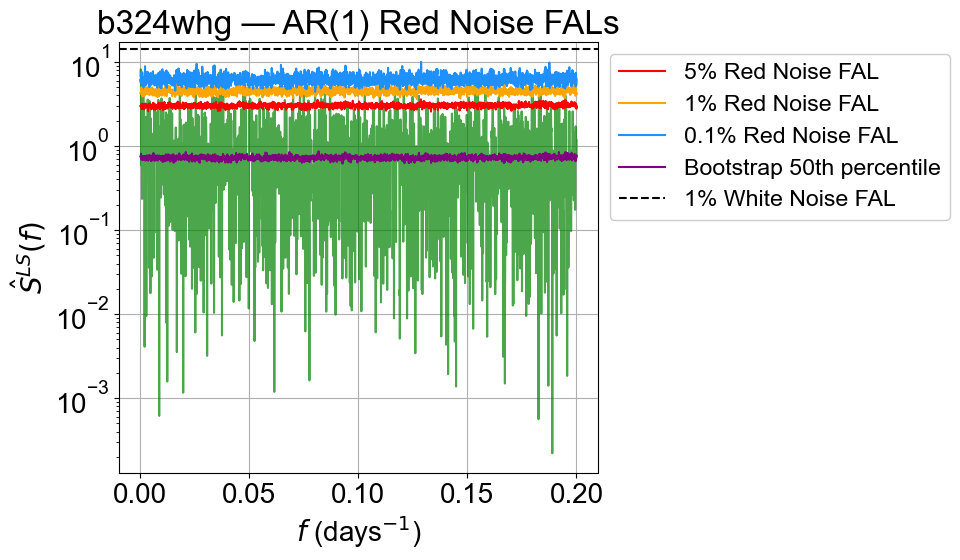

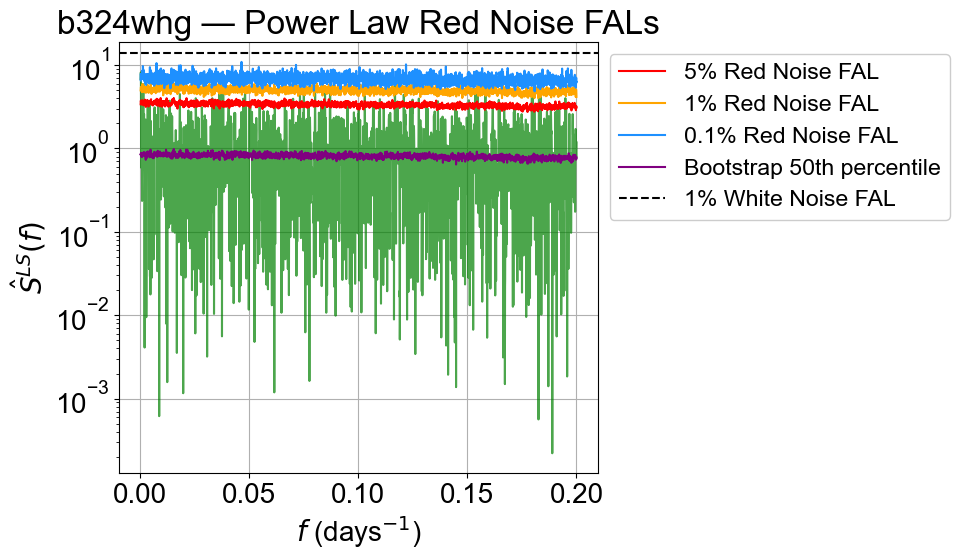


── b324whg — Period Detection Summary ──
  Frequency range searched: 0.00025 – 0.20000 day⁻¹
  Period range searched   : 5.0 – 4058.6 days
  Best period : 3044.047 days  (f = 0.00033 day⁻¹)
  Observed LS power : 9.4270
  AR(1) FAL thresholds at best frequency:
    5%   FAL : 2.9604
    1%   FAL : 4.2106
    0.1% FAL : 6.2559
  → Signal exceeds 0.1% red noise FAL (99.9% significant) ✓


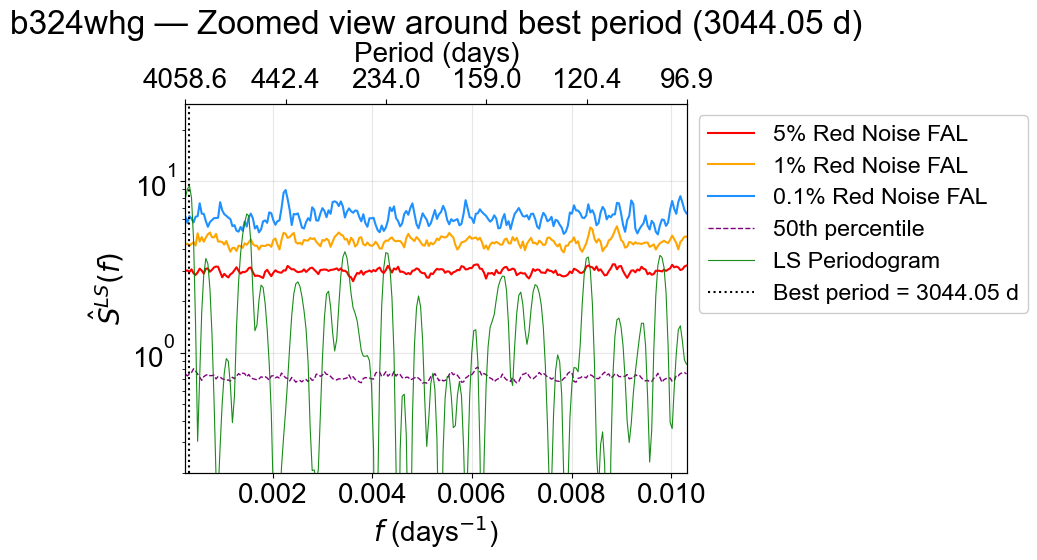

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import types
import os

from RedNoiseFALs import RedNoiseFALs

filename  = "b324whg.txt"
star_name = os.path.basename(filename).split(".")[0]  
print(f"Processing star: {star_name}")

mjd_list   = []
vmag_list  = []
verr_list  = []

with open(filename, 'r') as f:
    next(f) 
    for line in f:
        cols = line.strip().split()
        if len(cols) < 3:
            continue  
        
        try:
            mjd_val  = float(cols[0])
        except ValueError:
            continue 
        
        vmag_str = cols[1]
        verr_str = cols[2]
  
        if vmag_str in ("--.---", "---.---", "---") or verr_str in ("-.---", "--.---"):
            continue
        
        try:
            vmag_val = float(vmag_str)
            verr_val = float(verr_str)
        except ValueError:
            continue
        
        mjd_list.append(mjd_val)
        vmag_list.append(vmag_val)
        verr_list.append(verr_val)

mjd   = np.array(mjd_list)
V_mag = np.array(vmag_list)
V_err = np.array(verr_list)

print(f"Good V points: {len(V_mag)}")
print(f"MJD range: {mjd[0]:.1f} – {mjd[-1]:.1f}")
print(f"V mag range: {V_mag.min():.3f} – {V_mag.max():.3f}")

fmin = 1.0 / (mjd[-1] - mjd[0])
fmax = 0.2

rn = RedNoiseFALs(
    time       = mjd,
    obs        = V_mag,
    eobs       = V_err,
    fmax       = fmax,
    fmin       = fmin,
    detrending = True,
    plot       = True
)
plt.title(f"{star_name} — LS + White Noise FALs")
plt.tight_layout()
plt.show()

wl_pl,  slope,    intercept, _ = rn.pl_fit(
    x0=[-1.0, 0.0], plot_limits=[(-3, 0), (-3, 3)],
    Plot=True, Objective_plot=True
)
wl_ar1, phi,      sigma,     _ = rn.ar1_fit(
    x0=[0.5, 1.0],  plot_limits=[(0.001, 1), (0.5, 1.5)],
    Plot=True, Objective_plot=True
)
wl_wn,  power_wn,            _ = rn.wn_fit(
    x0=1.0,          plot_limits=[(0.5, 5)],
    Plot=True, Objective_plot=True
)
plt.show()

print(f"\n── Model comparison for {star_name} (lower NLL = better) ──")
print(f"  Power law   NLL: {wl_pl:.2f}  | slope={slope:.2f}, intercept={intercept:.2f}")
print(f"  AR(1)       NLL: {wl_ar1:.2f} | phi={phi:.2f}, sigma={sigma:.2f}")
print(f"  White noise NLL: {wl_wn:.2f}  | power={power_wn:.2f}")

best_model = min([("Power law", wl_pl), ("AR(1)", wl_ar1), ("White noise", wl_wn)],
                  key=lambda x: x[1])
print(f"  → Best model: {best_model[0]}")

save_file = f"{star_name}_fitting_results.txt"

if os.path.exists(save_file):
    print(f"\nLoading existing bootstrap results from {save_file}")
    results        = np.loadtxt(save_file, skiprows=1)
    dist_slope     = results[:, 1]
    dist_intercept = results[:, 2]
    dist_phi       = results[:, 4]
    dist_sigma     = results[:, 5]
    dist_pl_wl     = results[:, 0]
    dist_ar1_wl    = results[:, 3]
    dist_wn_wl     = results[:, 6]
else:
    print(f"\nRunning bootstrap (n=1000) — this may take a while...")
    dist_pl_wl, dist_ar1_wl, dist_wn_wl, \
    dist_slope, dist_intercept, \
    dist_phi, dist_sigma = rn.gen_distributions(
        n_bootstrap = 1000,
        histograms  = True,
        save_file   = save_file
    )
    plt.title(f"{star_name} — Whittle NLL Distributions")
    plt.tight_layout()
    plt.show()

print(f"  Median NLL — PL: {np.median(dist_pl_wl):.2f}, "
      f"AR(1): {np.median(dist_ar1_wl):.2f}, "
      f"WN: {np.median(dist_wn_wl):.2f}")

def fal_ar1(self, phi, sigma, n_bootstrap=10000, Plot=True, title="FALs based on AR(1)"):
    if isinstance(phi, np.ndarray) and isinstance(sigma, np.ndarray):
        if not (len(phi) == len(sigma) == n_bootstrap):
            print("Length of phi and sigma distributions must equal n_bootstrap")
            return

    t    = self.time[-1] - self.time[0]
    rr   = 0.5 / t
    fgrid = np.linspace(rr, self.fnyq, num=int((self.fnyq / rr) * 3), endpoint=True)

    if self.fmin != "Default":
        idx   = np.argmin(np.abs(fgrid - self.fmin))
        fgrid = fgrid[idx:]

    N_gridpoints = len(fgrid)  
    n            = len(self.time)
    spec         = np.zeros((N_gridpoints, n_bootstrap))
    rand_int     = np.random.randn(n_bootstrap)
    new_obs      = np.zeros(n)

    ls_real   = LombScargle(self.time, self.obs, normalization="psd")
    LS_real   = ls_real.power(fgrid)
    fal_white = ls_real.false_alarm_level([0.05, 0.01, 0.001], method='bootstrap')

    for j in range(n_bootstrap):
        phi_j   = phi[j]   if isinstance(phi,   np.ndarray) else phi
        sigma_j = sigma[j] if isinstance(sigma, np.ndarray) else sigma
        tau         = -1.0 / np.log(np.abs(phi_j))
        new_obs[0]  = rand_int[j]
        epsilon     = sigma_j * np.random.randn(n)
        for i in range(1, n):
            new_obs[i] = new_obs[i-1] * np.exp(-(self.time[i] - self.time[i-1]) / tau) + epsilon[i]
        Obs        = new_obs / np.std(new_obs)
        spec[:, j] = LombScargle(self.time, Obs, normalization="psd").power(fgrid)

    percentiles = np.percentile(spec, [95.0, 99.0, 99.9, 50.0], axis=1).T

    if Plot:
        plt.figure(figsize=(10, 6))
        plt.title(title)
        plt.xlabel(r"$f$ (days$^{-1}$)")
        plt.ylabel(r"$\hat{S}^{LS}(f)$")
        plt.semilogy(fgrid, LS_real,            color="green",      alpha=0.7)
        plt.semilogy(fgrid, percentiles[:, 0],  color="red",        label="5% Red Noise FAL")
        plt.semilogy(fgrid, percentiles[:, 1],  color="orange",     label="1% Red Noise FAL")
        plt.semilogy(fgrid, percentiles[:, 2],  color="dodgerblue", label="0.1% Red Noise FAL")
        plt.semilogy(fgrid, percentiles[:, 3],  color="purple",     label=r"Bootstrap 50th percentile")
        plt.axhline(fal_white[1], linestyle='--', color='black',    label="1% White Noise FAL")
        plt.grid(axis="both")
        plt.legend(fontsize='small', facecolor='white', framealpha=1, bbox_to_anchor=(1.0, 1.0))
    return percentiles, fgrid


def fal_pl(self, slope, intercept, n_bootstrap=10000, Plot=True, title="FALs based on power law"):
    if isinstance(slope, np.ndarray) and isinstance(intercept, np.ndarray):
        if not (len(slope) == len(intercept) == n_bootstrap):
            print("Length of slope and intercept distributions must equal n_bootstrap")
            return

    t     = self.time[-1] - self.time[0]
    rr    = 0.5 / t
    fgrid = np.linspace(rr, self.fnyq, num=int((self.fnyq / rr) * 3), endpoint=True)

    if self.fmin != "Default":
        idx   = np.argmin(np.abs(fgrid - self.fmin))
        fgrid = fgrid[idx:]

    N_gridpoints = len(fgrid) 
    n            = len(self.time)
    flog         = np.log10(fgrid)
    delta_w      = 2 * np.pi * (fgrid[1] - fgrid[0])
    time_shifted = self.time - self.time[0]
    spec         = np.zeros((N_gridpoints, n_bootstrap))
    rand_int     = np.random.randn(n_bootstrap)

    ls_real   = LombScargle(self.time, self.obs, normalization="psd")
    LS_real   = ls_real.power(fgrid)
    fal_white = ls_real.false_alarm_level([0.05, 0.01, 0.001], method='bootstrap')

    for j in range(n_bootstrap):
        slope_j     = slope[j]     if isinstance(slope,     np.ndarray) else slope
        intercept_j = intercept[j] if isinstance(intercept, np.ndarray) else intercept
        ps_pl       = 10 ** (slope_j * flog + intercept_j)
        phi_k       = np.random.rand(N_gridpoints) * 2 * np.pi
        new_obs     = np.zeros(n)
        for i in range(n):
            new_obs[i] = np.sum(np.sqrt(ps_pl * delta_w) * np.cos(2 * np.pi * fgrid * time_shifted[i] + phi_k))
        new_obs    = new_obs / np.std(new_obs)
        spec[:, j] = LombScargle(time_shifted, new_obs, normalization="psd").power(fgrid)

    percentiles = np.percentile(spec, [95.0, 99.0, 99.9, 50.0], axis=1).T

    if Plot:
        plt.figure(figsize=(10, 6))
        plt.title(title)
        plt.xlabel(r"$f$ (days$^{-1}$)")
        plt.ylabel(r"$\hat{S}^{LS}(f)$")
        plt.semilogy(fgrid, LS_real,            color="green",      alpha=0.7)
        plt.semilogy(fgrid, percentiles[:, 0],  color="red",        label="5% Red Noise FAL")
        plt.semilogy(fgrid, percentiles[:, 1],  color="orange",     label="1% Red Noise FAL")
        plt.semilogy(fgrid, percentiles[:, 2],  color="dodgerblue", label="0.1% Red Noise FAL")
        plt.semilogy(fgrid, percentiles[:, 3],  color="purple",     label=r"Bootstrap 50th percentile")
        plt.axhline(fal_white[1], linestyle='--', color='black',    label="1% White Noise FAL")
        plt.grid(axis="both")
        plt.legend(fontsize='small', facecolor='white', framealpha=1, bbox_to_anchor=(1.0, 1.0))
    return percentiles, fgrid

rn.fal_ar1 = types.MethodType(fal_ar1, rn)
rn.fal_pl  = types.MethodType(fal_pl,  rn)

percentiles_ar1, fgrid_ar1 = rn.fal_ar1(
    phi=dist_phi, sigma=dist_sigma, n_bootstrap=1000,
    title=f"{star_name} — AR(1) Red Noise FALs"
)
plt.tight_layout()
plt.show()

percentiles_pl, fgrid_pl = rn.fal_pl(
    slope=dist_slope, intercept=dist_intercept, n_bootstrap=1000,
    title=f"{star_name} — Power Law Red Noise FALs"
)
plt.tight_layout()
plt.show()

V_norm   = (V_mag - np.mean(V_mag)) / np.std(V_mag)
LS_power = LombScargle(mjd, V_norm, normalization="psd").power(fgrid_ar1)

min_len         = min(len(fgrid_ar1), len(percentiles_ar1))
fgrid_ar1       = fgrid_ar1[:min_len]
LS_power        = LS_power[:min_len]
percentiles_ar1 = percentiles_ar1[:min_len]

best_idx    = np.argmax(LS_power)
best_freq   = fgrid_ar1[best_idx]
best_period = 1.0 / best_freq
best_power  = LS_power[best_idx]

idx_best = best_idx

print(f"\n── {star_name} — Period Detection Summary ──")
print(f"  Frequency range searched: {fgrid_ar1[0]:.5f} – {fgrid_ar1[-1]:.5f} day⁻¹")
print(f"  Period range searched   : {1/fgrid_ar1[-1]:.1f} – {1/fgrid_ar1[0]:.1f} days")
print(f"  Best period : {best_period:.3f} days  (f = {best_freq:.5f} day⁻¹)")
print(f"  Observed LS power : {best_power:.4f}")
print(f"  AR(1) FAL thresholds at best frequency:")
print(f"    5%   FAL : {percentiles_ar1[idx_best, 0]:.4f}")
print(f"    1%   FAL : {percentiles_ar1[idx_best, 1]:.4f}")
print(f"    0.1% FAL : {percentiles_ar1[idx_best, 2]:.4f}")

if best_power > percentiles_ar1[idx_best, 2]:
    print("  → Signal exceeds 0.1% red noise FAL (99.9% significant) ✓")
elif best_power > percentiles_ar1[idx_best, 1]:
    print("  → Signal exceeds 1% red noise FAL (99% significant) ✓")
elif best_power > percentiles_ar1[idx_best, 0]:
    print("  → Signal exceeds 5% red noise FAL (95% significant) ✓")
else:
    print("  → Signal does NOT exceed 5% red noise FAL — not significant against red noise ✗")

freq_range  = fgrid_ar1[-1] - fgrid_ar1[0]
zoom_half   = freq_range * 0.05    
freq_lo     = max(fgrid_ar1[0],  best_freq - zoom_half)
freq_hi     = min(fgrid_ar1[-1], best_freq + zoom_half)

zoom_mask        = (fgrid_ar1 >= freq_lo) & (fgrid_ar1 <= freq_hi)
fgrid_zoom       = fgrid_ar1[zoom_mask]
LS_zoom          = LS_power[zoom_mask]
percentiles_zoom = percentiles_ar1[zoom_mask]

if len(fgrid_zoom) == 0:
    print("\nWARNING: Zoom window is empty — best period may be outside FAL frequency range.")
    print(f"  FAL range: {1/fgrid_ar1[-1]:.1f} – {1/fgrid_ar1[0]:.1f} days")
    print(f"  Best period: {best_period:.1f} days")
    print("  → Try expanding fmax/fmin to include this period.")
else:
    y_floor = percentiles_zoom[:, 3].min() * 0.3
    y_ceil  = max(LS_zoom.max(), percentiles_zoom[:, 2].max()) * 3.0

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title(f"{star_name} — Zoomed view around best period ({best_period:.2f} d)")

    ax.semilogy(fgrid_zoom, percentiles_zoom[:, 0], color="red",        lw=1.5, label="5% Red Noise FAL")
    ax.semilogy(fgrid_zoom, percentiles_zoom[:, 1], color="orange",     lw=1.5, label="1% Red Noise FAL")
    ax.semilogy(fgrid_zoom, percentiles_zoom[:, 2], color="dodgerblue", lw=1.5, label="0.1% Red Noise FAL")
    ax.semilogy(fgrid_zoom, percentiles_zoom[:, 3], color="purple",     lw=1.0,
                linestyle="--", label="50th percentile")

    ax.semilogy(fgrid_zoom, LS_zoom, color="green", alpha=0.9, lw=0.8,
                zorder=5, label="LS Periodogram")

    ax.axvline(best_freq, color="black", linestyle=":", lw=1.5,
               label=f"Best period = {best_period:.2f} d")

    ax.set_ylim(y_floor, y_ceil)
    ax.set_xlim(freq_lo, freq_hi)

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    tick_freqs = np.linspace(freq_lo, freq_hi, 6)
    ax2.set_xticks(tick_freqs)
    ax2.set_xticklabels([f"{1/f:.1f}" for f in tick_freqs])
    ax2.set_xlabel("Period (days)")

    ax.set_xlabel(r"$f$ (days$^{-1}$)")
    ax.set_ylabel(r"$\hat{S}^{LS}(f)$")
    ax.grid(axis="both", alpha=0.3)
    ax.legend(fontsize='small', facecolor='white', framealpha=1, bbox_to_anchor=(1.0, 1.0))
    plt.tight_layout()
    plt.show()

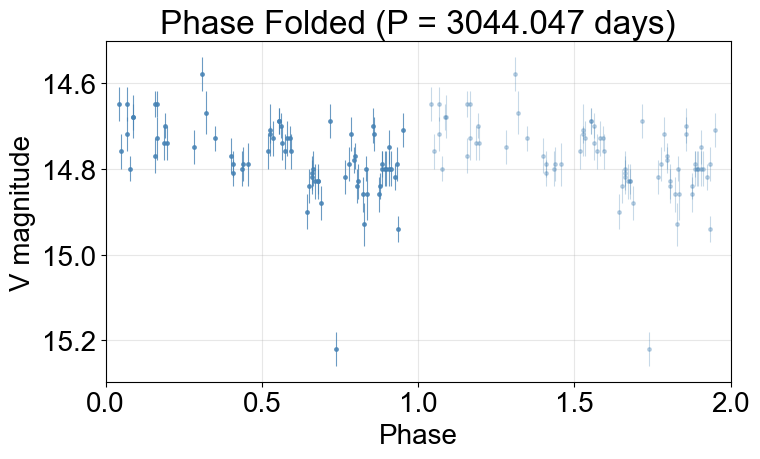

In [ ]:
def phase_fold_plot(mjd, V_mag, V_err, period, star_name):
    phase = (mjd % period) / period

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(phase,     V_mag, yerr=V_err, fmt='.', color='steelblue',
                alpha=0.8, markersize=5, elinewidth=0.8)
    ax.errorbar(phase + 1, V_mag, yerr=V_err, fmt='.', color='steelblue',
                alpha=0.3, markersize=5, elinewidth=0.8)

    ax.invert_yaxis()
    ax.set_xlabel("Phase")
    ax.set_ylabel("V magnitude")
    ax.set_title(f"Phase Folded (P = {period:.3f} days)")
    ax.set_xlim(0, 2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

phase_fold_plot(mjd, V_mag, V_err, best_period, star_name)